In [ ]:
#-------ACCESS TO GOOGLE DRIVE IN COLAB-------
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
#!unzip /content/drive/MyDrive/CT/Proj.zip -d ./dane

In [5]:
import os
import re
import numpy as np
import torch
import torch.nn.functional as F
import tifffile
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
# =========================================================
# 1. Parameters and GPU setup
# =========================================================
data_dir = "./dane/Proj"
proj_step = 6
voxel_size = 0.0525828
DSO = 359.968 / voxel_size
DSD = 848.871 / voxel_size
total_projections_360 = 1952

# Offsets from XML file (in pixels, converted to voxels)
cor_offset = 0.0
vertical_offset = -25.5224 / voxel_size  # Shift in voxels (negative because it's upwards)

# Volume parameters
Z_slices = 100          # Number of slices in the reconstructed volume
H_rec = 2536            # Full height
W_rec = 2024            # Full width
Z_batch_size = 16        # Small batch size for reconstruction (adjust based on GPU memory)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

# =========================================================
# 2. PREPARATION OF FILES AND FILTER (WITH HAMMING WINDOW)
# =========================================================
def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]

all_files = sorted([f for f in os.listdir(data_dir) if f.lower().endswith((".tif", ".tiff"))],
                   key=natural_sort_key)
selected_files = all_files[::proj_step]

sample_img = tifffile.imread(os.path.join(data_dir, selected_files[0]))
H_proj, W_proj = sample_img.shape[:2]

# Filtration in the frequency domain - preparing the filter
n_fft = int(2**np.ceil(np.log2(W_proj)))
freqs = torch.fft.fftfreq(n_fft, device=device)
filter_fft = torch.abs(freqs)

# Hamming window to reduce ringing artifacts
filter_fft *= (0.54 + 0.46 * torch.cos(2 * np.pi * freqs))
filter_fft[0] = 0 # Usuwanie DC

# =========================================================
# 3. Cosinus weighting of projections
# =========================================================
# Detector grid coordinates (u, v) with offsets
vv_1d = torch.arange(H_proj, device=device) - (H_proj / 2) - vertical_offset
uu_1d = torch.arange(W_proj, device=device) - (W_proj / 2) - cor_offset

# 2D grid of detector coordinates
vv_grid, uu_grid = torch.meshgrid(vv_1d, uu_1d, indexing='ij')

# Calculate cosine weight: DSD / sqrt(DSD^2 + u^2 + v^2)
cosine_weight = DSD / torch.sqrt(DSD**2 + uu_grid**2 + vv_grid**2)

Używane urządzenie: cuda


In [ ]:
# =========================================================
# 4. BATCH LOOP OVER SLICES
# =========================================================
recon_volume_full = np.zeros((Z_slices, H_rec, W_rec), dtype=np.float32)

for z_start in range(0, Z_slices, Z_batch_size):
    z_end = min(z_start + Z_batch_size, Z_slices)
    current_slab_h = z_end - z_start

    print(f"\n--- Rekonstrukcja warstw {z_start} do {z_end} | Rozmiar {W_rec}x{H_rec} ---")

    slab_gpu = torch.zeros((current_slab_h, H_rec, W_rec), device=device)

    # Grid in object domain
    z_coords = torch.linspace(z_start - Z_slices//2, z_end - Z_slices//2, current_slab_h, device=device)
    y_coords = torch.linspace(-H_rec//2, H_rec//2, H_rec, device=device)
    x_coords = torch.linspace(-W_rec//2, W_rec//2, W_rec, device=device)
    zz, yy, xx = torch.meshgrid(z_coords, y_coords, x_coords, indexing='ij')

    for idx, filename in enumerate(tqdm(selected_files, desc="Przetwarzanie")):

        img = tifffile.imread(os.path.join(data_dir, filename)).astype(np.float32)
        if img.ndim == 3: img = img[..., 0]

        img_t = torch.from_numpy(img).to(device)
        I0 = torch.quantile(img_t, 0.995)
        img_log = torch.log(torch.clamp(I0 / torch.clamp(img_t, min=1e-3), min=1e-3))
        # ---  Added FDK correction---
        img_weighted = img_log * cosine_weight

        proj_fft = torch.fft.fft(img_log, n=n_fft, dim=1)
        filtered_proj = torch.real(torch.fft.ifft(proj_fft * filter_fft, dim=1))[:, :W_proj]

        # B. Geometry and projection mapping
        actual_idx = idx * proj_step
        theta = -2 * np.pi * actual_idx / total_projections_360
        cos_t, sin_t = np.cos(theta), np.sin(theta)

        L = DSO + (xx * sin_t - yy * cos_t)
        U = DSO / L


        det_x = (DSO * (xx * cos_t + yy * sin_t) / L) + (W_proj / 2) + cor_offset
        det_y = (DSO * zz / L) + (H_proj / 2) + vertical_offset

        # C. Backprojection
        u_norm = (det_x / (W_proj - 1)) * 2 - 1
        v_norm = (det_y / (H_proj - 1)) * 2 - 1
        w_norm = torch.zeros_like(u_norm) # Obraz 2D

        grid = torch.stack((u_norm, v_norm, w_norm), dim=-1).unsqueeze(0)
        proj_input = filtered_proj.unsqueeze(0).unsqueeze(0).unsqueeze(0)

        sampled = F.grid_sample(proj_input, grid, mode='bilinear', padding_mode='zeros', align_corners=True)

        # 6. Acumulation with weight U**2
        slab_gpu += sampled.squeeze() * (U**2)

    # Writing to RAM (CPU)
    recon_volume_full[z_start:z_end] = (slab_gpu / len(selected_files)).cpu().numpy()

    del slab_gpu, zz, yy, xx, grid, proj_input
    torch.cuda.empty_cache()


--- Rekonstrukcja warstw 0 do 16 | Rozmiar 2024x2536 ---


Przetwarzanie: 100%|██████████| 326/326 [00:42<00:00,  7.67it/s]



--- Rekonstrukcja warstw 16 do 32 | Rozmiar 2024x2536 ---


Przetwarzanie: 100%|██████████| 326/326 [00:41<00:00,  7.82it/s]



--- Rekonstrukcja warstw 32 do 48 | Rozmiar 2024x2536 ---


...

Przetwarzanie: 100%|██████████| 326/326 [00:41<00:00,  7.82it/s]



--- Rekonstrukcja warstw 80 do 96 | Rozmiar 2024x2536 ---


Przetwarzanie: 100%|██████████| 326/326 [00:41<00:00,  7.81it/s]



--- Rekonstrukcja warstw 96 do 100 | Rozmiar 2024x2536 ---


Przetwarzanie: 100%|██████████| 326/326 [00:13<00:00, 24.88it/s]


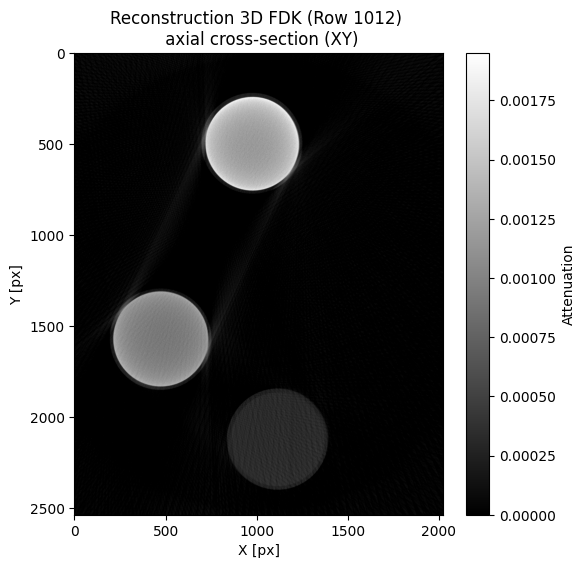

In [ ]:
# Axial cross-section visualization
recon_volume_full = np.maximum(recon_volume_full, 0)
plt.rc('text', usetex=False)
plt.figure(figsize=(6, 6))
plt.imshow(recon_volume_full[Z_slices // 2], cmap='gray')
plt.title("Reconstruction 3D FDK (Row 1012) \n axial cross-section (XY)")
plt.xlabel("X [px]")
plt.ylabel("Y [px]")
plt.colorbar(label='Attenuation')
plt.savefig("FDK.png")
plt.show()

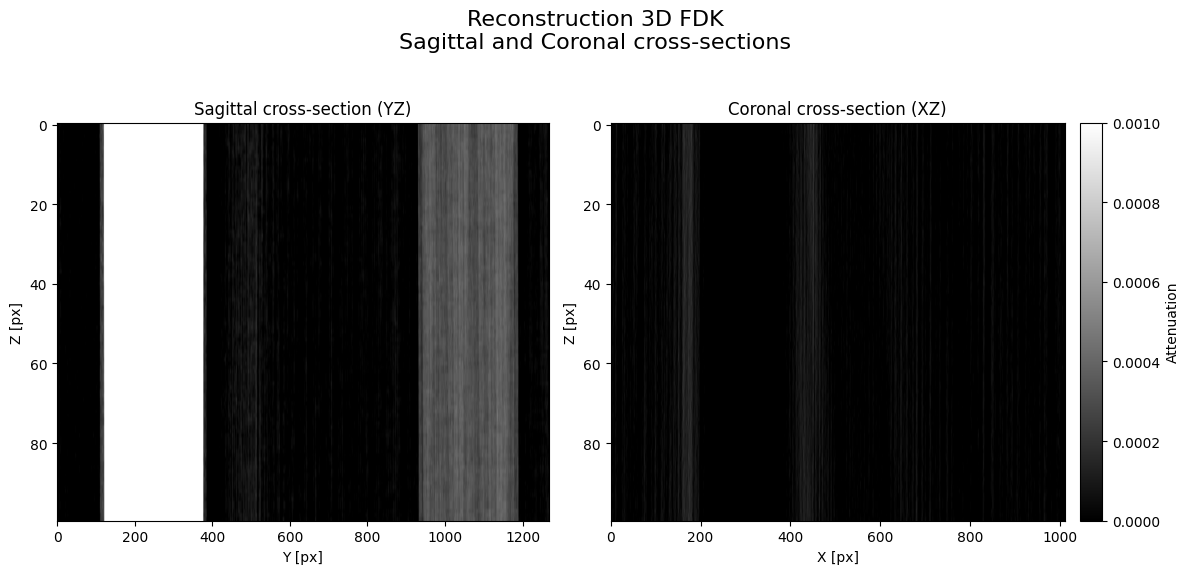

In [ ]:
# --- Parameters settings ---
#visualization parameters axial and sagital/coronal cross-sections
moje_vmax = 0.0010  # <--- Maximal allowed value for display (adjust based on your data) ---
tytul = "Reconstruction 3D FDK\nSagittal and Coronal cross-sections"

mid_z = recon_volume_full.shape[0] // 2
mid_y = recon_volume_full.shape[1] // 2
mid_x = recon_volume_full.shape[2] // 2

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im0 = ax[0].imshow(recon_volume_full[:, ::2, mid_x],
                   cmap='gray',
                   aspect='auto',
                   vmin=0,
                   vmax=moje_vmax)
ax[0].set_title("Sagittal cross-section (YZ)")
ax[0].set_xlabel("Y [px]")
ax[0].set_ylabel("Z [px]")

im1 = ax[1].imshow(recon_volume_full[:, mid_y, ::2],
                   cmap='gray',
                   aspect='auto',
                   vmin=0,
                   vmax=moje_vmax)
ax[1].set_title("Coronal cross-section (XZ)")
ax[1].set_xlabel("X [px]")
ax[1].set_ylabel("Z [px]")

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
fig.colorbar(im1, cax=cax, label='Attenuation')

fig.suptitle(tytul, fontsize=16)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.savefig("FDK_3D_att0010.png", bbox_inches='tight')
plt.show()

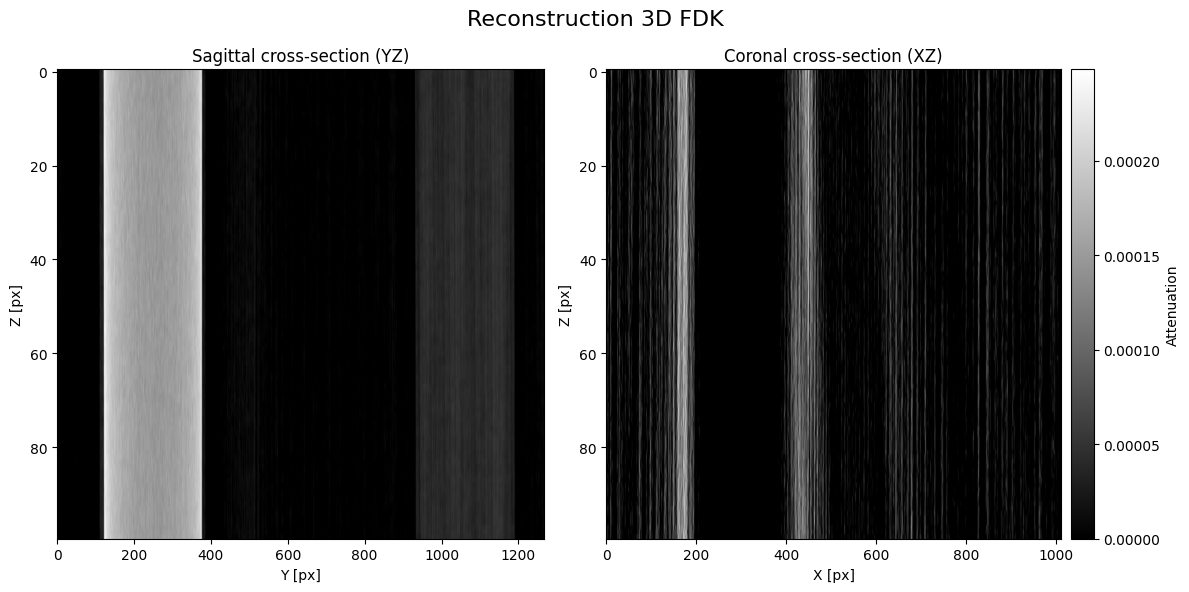

In [ ]:
mid_z = recon_volume_full.shape[0] // 2
mid_y = recon_volume_full.shape[1] // 2
mid_x = recon_volume_full.shape[2] // 2

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im1 = ax[1].imshow(recon_volume_full[:, mid_y, ::2], cmap='gray', aspect='auto')
ax[1].set_title("Coronal cross-section (XZ)")
ax[1].set_xlabel("X [px]")
ax[1].set_ylabel("Z [px]")


im2 = ax[0].imshow(recon_volume_full[:, ::2, mid_x], cmap='gray', aspect='auto')
ax[0].set_title("Sagittal cross-section (YZ)")

ax[0].set_xlabel("Y [px]")
ax[0].set_ylabel("Z [px]")

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax, label='Attenuation')
fig.suptitle("Reconstruction 3D FDK", fontsize=16)
plt.tight_layout()
plt.savefig("FDK_3D.png")
plt.show()

In [2]:
from ipywidgets import interact, IntSlider, VBox

def interactive_thick_coronal(volume):
    z_dim, y_dim, x_dim = volume.shape

    def update_thick_plot(center_y, thickness):
        # Obliczamy zakres warstw (od-do)
        half = thickness // 2
        start_y = max(0, center_y - half)
        end_y = min(y_dim, center_y + half + 1)

        # Tworzymy "gruby plaster" (MIP wzdłuż osi Y)
        # Bierzemy plaster z osi Y (głębokość), rzutując na płaszczyznę XZ
        slab = np.max(volume[:, start_y:end_y, :], axis=1)

        plt.figure(figsize=(12, 7))
        # aspect='auto' jest ważne, bo oś Z (pionowa) może mieć inną skalę niż X
        plt.imshow(slab[::2, ::2], cmap='gray', aspect='auto')

        plt.title(f"Gruby przekrój Coronal | Centrum Y: {center_y} | Grubość: {thickness} warstw")
        plt.xlabel("Oś X [px]")
        plt.ylabel("Oś Z (Wysokość) [px]")
        plt.colorbar(label="Max Intensity")
        plt.show()

    # Suwaki
    center_slider = IntSlider(min=0, max=y_dim-1, step=1, value=y_dim//2, description='Pozycja Y:')
    thick_slider = IntSlider(min=1, max=200, step=1, value=50, description='Grubość:')

    interact(update_thick_plot, center_y=center_slider, thickness=thick_slider)

# Uruchomienie dla Twojego wolumenu
#interactive_thick_coronal(recon_volume_full)

In [7]:
# Preparaion for animation
#fig, ax = plt.subplots(figsize=(10, 6))
#z_dim, y_dim, x_dim = recon_volume_full.shape
#thickness = 200 # grubość plastra

# Function for one frame of animation - it returns the "thick slab" for a given center Y
#def get_slab(y_center):
#    start_y = max(0, y_center - thickness // 2)
#    end_y = min(y_dim, y_center + thickness // 2 + 1)
    # Tworzymy gruby plaster
#    return np.max(recon_volume_full[:, start_y:end_y, :], axis=1)

# Fisrt frame
#im = ax.imshow(get_slab(thickness//2)[::2, ::2], cmap='gray', aspect='auto')
#ax.axis('off')
#title = ax.set_title("Automatyczny przelot przez wolumen (Coronal)")

#def update(y_center):
#    slab = get_slab(y_center)
#    im.set_data(slab[::2, ::2])
#    title.set_text(f"Przekrój Coronal | Pozycja Y: {y_center}")
#    return [im]

# Creating the animation - 'frames' are the different Y positions
#ani = FuncAnimation(fig, update, frames=range(thickness//2, y_dim-thickness//2, 10),
#                    interval=50, blit=True)

#plt.close()
#HTML(ani.to_jshtml())

In [8]:
# --- 3D Animated Visualization of All Three Planes ---

#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
#z_dim, y_dim, x_dim = recon_volume_full.shape

#im1 = ax1.imshow(recon_volume_full[z_dim//2, ::2, ::2], cmap='gray')
#ax1.set_title("Axial (XY) - Góra/Dół")

#im2 = ax2.imshow(np.max(recon_volume_full[:, y_dim//2-10:y_dim//2+10, ::2], axis=1), cmap='gray', aspect='auto')
#ax2.set_title("Coronal (XZ) - Przód/Tył")

#im3 = ax3.imshow(np.max(recon_volume_full[:, ::2, x_dim//2-10:x_dim//2+10], axis=2), cmap='gray', aspect='auto')
#ax3.set_title("Sagittal (YZ) - Bok")

#for ax in [ax1, ax2, ax3]: ax.axis('off')

#def update(frame):
#    idx_z = int((frame / 100) * (z_dim - 1))
#    idx_y = int((frame / 100) * (y_dim - 1))
#    idx_x = int((frame / 100) * (x_dim - 1))

#    im1.set_data(recon_volume_full[idx_z, ::2, ::2])

#    thickness = 40
#    y_start, y_end = max(0, idx_y-thickness//2), min(y_dim, idx_y+thickness//2)
#    slab_c = np.max(recon_volume_full[:, y_start:y_end, ::2], axis=1)
#    im2.set_data(slab_c)

#    x_start, x_end = max(0, idx_x-thickness//2), min(x_dim, idx_x+thickness//2)
#    slab_s = np.max(recon_volume_full[:, ::2, x_start:x_end], axis=2)
#    im3.set_data(slab_s)

#    return [im1, im2, im3]

#ani = FuncAnimation(fig, update, frames=np.linspace(0, 100, 50), interval=100, blit=True)

#plt.close()
#HTML(ani.to_jshtml())